SKŁAD GRUP  ('krawędzie' = ile par w grupie ma |r| > prog)

Pearson: 11 grup
   F2, F3, F4, F8, F9, F14, F15, F20, F21, F26, F27 krawędzie  55/55   repr. F3
   F7, F11, F28                                     krawędzie   3/3    repr. F7
   F10, F13, F17                                    krawędzie   3/3    repr. F13
   F16, F19, F23                                    krawędzie   3/3    repr. F16
   F22, F25, F29                                    krawędzie   3/3    repr. F25
   F1, F5                                           krawędzie   1/1    repr. F1
   pojedyncze: F6, F12, F18, F24, F30

Spearman: 11 grup
   F2, F3, F4, F8, F9, F14, F15, F20, F21, F26, F27 krawędzie  55/55   repr. F3
   F7, F11, F28                                     krawędzie   3/3    repr. F7
   F10, F13, F17                                    krawędzie   3/3    repr. F13
   F16, F19, F23                                    krawędzie   3/3    repr. F16
   F22, F25, F29                                    krawędzie

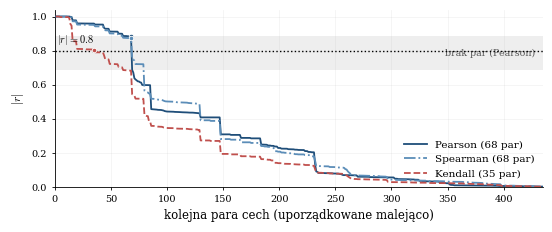

In [5]:
"""
Rysunek 4.1 -- uzasadnienie progu korelacji.

Jeden panel: uporządkowane malejąco wartości |r| dla wszystkich 435 par
cech, osobno dla trzech współczynników. Pokazuje dwie rzeczy naraz:

  1. próg 0.8 trafia w wyraźną przerwę rozkładu dla Pearsona i Spearmana
     (zacieniony pas -- żadna para nie ma |r| w tym zakresie),
  2. krzywa Kendalla leży systematycznie niżej i przecina próg w środku
     gładkiego zbocza, co tłumaczy odmienną liczbę grup oraz jej
     niestabilność względem progu (por. tabela wrażliwości z raport()).

Skład grup i wrażliwość na próg podaje funkcja raport() -- te informacje
idą do pracy jako tabele, nie jako rysunek.

PDF zapisywany w rozmiarze docelowym -> wstawiać BEZ skalowania.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx

# ============================================================
# KONFIGURACJA
# ============================================================

SCIEZKA_DANYCH = "../data/processed/FULL_30.npz"
KLUCZ_X = "X"

PROG = 0.8
WSP_PRZERWA = "Pearson"      # dla którego współczynnika zacieniać przerwę
TEXT_WIDTH_IN = 6.3
WYSOKOSC_IN = 2.3
PLIK_WY = "rysunek_4_1_prog.pdf"

REPREZENTANCI = {
    "F1", "F3", "F5", "F6", "F7", "F12",
    "F13", "F16", "F18", "F24", "F25", "F30",
}

STYL = {
    "Pearson":  ("#1f4e79", "-"),
    "Spearman": ("#5b8db8", "-."),
    "Kendall":  ("#c0504d", "--"),
}

mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})


# ============================================================
# DANE
# ============================================================

def wczytaj_dane(sciezka=SCIEZKA_DANYCH, klucz=KLUCZ_X):
    X = np.load(sciezka, allow_pickle=True)[klucz]
    return pd.DataFrame(X, columns=[f"F{i}" for i in range(1, X.shape[1] + 1)])


def macierze_korelacji(df):
    return {
        "Pearson": df.corr(method="pearson"),
        "Spearman": df.corr(method="spearman"),
        "Kendall": df.corr(method="kendall"),
    }


def pary_malejaco(C):
    """Wartości |r| dla wszystkich par, uporządkowane malejąco."""
    n = C.shape[0]
    return np.sort(np.abs(C.values)[np.triu_indices(n, k=1)])[::-1]


def grupy(C, prog=PROG):
    G = nx.Graph()
    G.add_nodes_from(C.columns)
    A = np.abs(C.values)
    n = len(C.columns)
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > prog:
                G.add_edge(C.columns[i], C.columns[j])
    sklad = sorted(
        (sorted(k, key=lambda s: int(s[1:])) for k in nx.connected_components(G)),
        key=lambda g: (-len(g), int(g[0][1:])),
    )
    return sklad, G


# ============================================================
# DIAGNOSTYKA -- materiał do tabel w pracy
# ============================================================

def raport(df):
    M = macierze_korelacji(df)
    n = df.shape[1]

    print("=" * 68)
    print("SKŁAD GRUP  ('krawędzie' = ile par w grupie ma |r| > prog)")
    print("=" * 68)
    for nazwa, C in M.items():
        sklad, G = grupy(C)
        print(f"\n{nazwa}: {len(sklad)} grup")
        for x in sklad:
            if len(x) == 1:
                continue
            kraw = G.subgraph(x).number_of_edges()
            mozliwe = len(x) * (len(x) - 1) // 2
            rep = sorted(set(x) & REPREZENTANCI)
            print(f"   {', '.join(x):<48s} krawędzie {kraw:>3d}/{mozliwe:<3d}"
                  f"  repr. {rep[0] if rep else '?'}")
        samotne = [x[0] for x in sklad if len(x) == 1]
        print(f"   pojedyncze: {', '.join(samotne)}")

    print("\n" + "=" * 68)
    print("PARA F1--F5")
    print("=" * 68)
    r_p = abs(M["Pearson"].loc["F1", "F5"])
    for nazwa, C in M.items():
        v = abs(C.loc["F1", "F5"])
        print(f"  {nazwa:9s} |r| = {v:.4f}   {'>' if v > PROG else '<'} {PROG}")
    print(f"\n  tau przewidziane z Pearsona (rozkład normalny):"
          f"  (2/pi)*arcsin({r_p:.4f}) = {(2/np.pi)*np.arcsin(r_p):.4f}")

    print("\n" + "=" * 68)
    print("WRAŻLIWOŚĆ NA PRÓG  (liczba grup)")
    print("=" * 68)
    print(f"{'prog':>6} | " + " | ".join(f"{k:>8}" for k in M))
    for p in (0.70, 0.75, 0.80, 0.85, 0.90, 0.95):
        print(f"{p:>6.2f} | " +
              " | ".join(f"{len(grupy(C, p)[0]):>8d}" for C in M.values()))

    print("\n" + "=" * 68)
    print("PRZERWA WOKÓŁ PROGU")
    print("=" * 68)
    for nazwa, C in M.items():
        war = pary_malejaco(C)
        k = int((war > PROG).sum())
        nad = war[k - 1] if k > 0 else np.nan
        pod = war[k] if k < war.size else np.nan
        print(f"  {nazwa:9s} par nad progiem: {k:>3d}/{war.size}"
              f"   ostatnia nad: {nad:.4f}   pierwsza pod: {pod:.4f}"
              f"   przerwa: {nad - pod:.4f}")
    return M


# ============================================================
# RYSUNEK
# ============================================================

def rysuj(df, plik=PLIK_WY):
    M = macierze_korelacji(df)

    fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN, WYSOKOSC_IN))

    # --- zacieniona przerwa (obszar bez żadnej pary) -------------------
    war_ref = pary_malejaco(M[WSP_PRZERWA])
    k_ref = int((war_ref > PROG).sum())
    if 0 < k_ref < war_ref.size:
        gora, dol = war_ref[k_ref - 1], war_ref[k_ref]
        ax.axhspan(dol, gora, color="0.5", alpha=0.13, lw=0, zorder=0)
        ax.text(war_ref.size * 0.985, (gora + dol) / 2,
                f"brak par ({WSP_PRZERWA})",
                fontsize=6.8, color="0.35", ha="right", va="center", zorder=1)

    # --- krzywe --------------------------------------------------------
    for nazwa, (kolor, ls) in STYL.items():
        war = pary_malejaco(M[nazwa])
        k = int((war > PROG).sum())
        ax.plot(np.arange(1, war.size + 1), war,
                lw=1.3, ls=ls, color=kolor, zorder=3,
                label=f"{nazwa} ({k} par)")
        # punkt przecięcia progu
        ax.plot([k], [war[k - 1]], marker="o", ms=3.2,
                color=kolor, mec="white", mew=0.6, zorder=4)

    ax.axhline(PROG, ls=":", lw=1.0, color="black", zorder=2)
    ax.text(0.004, PROG + 0.02, rf"$|r| = {PROG}$",
            transform=ax.get_yaxis_transform(), fontsize=7.5, va="bottom")

    ax.set_xlabel("kolejna para cech (uporządkowane malejąco)", fontsize=8.5)
    ax.set_ylabel(r"$|r|$", fontsize=8.5)
    ax.set_xlim(0, war.size)
    ax.set_ylim(0, 1.04)
    ax.tick_params(labelsize=7, length=2)
    ax.legend(fontsize=7.5, frameon=False, loc="lower right",
              handlelength=2.2, borderaxespad=0.4)
    ax.grid(alpha=0.18, lw=0.5)
    ax.set_axisbelow(True)
    for bok in ("top", "right"):
        ax.spines[bok].set_visible(False)

    fig.savefig(plik, bbox_inches="tight", pad_inches=0.02)
    print(f"\nZapisano: {Path(plik).resolve()}")
    return fig



dane = wczytaj_dane()
raport(dane)
rysuj(dane)
plt.show()